In [ ]:
#import all the necessary libraiees:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder

In [ ]:
#load the dataset:
df=pd.read_csv('/content/loan_data.csv')
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


**EDA(exploratory data analysis)**

In [ ]:
#fetch the top rows (default 5 rows)from the dataset :
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
#to fetch the botton rows (by default 5 rows) from the dataset:
df.tail()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [ ]:
#to fetch all the information from the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
#checking missing values in the dataset:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
#summary of the data :to fetch all the statistical information from the dataset:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
#here max(age) is 144 but that is not realistic so filter them :
df=df[df['person_age']<=100]
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44993.000000,4.499300e+04,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000
mean,27.748428,7.990845e+04,5.394528,9583.176761,11.006448,0.139736,5.866557,632.585713,0.222257
std,5.909737,6.332213e+04,5.927159,6314.802655,2.978985,0.087207,3.877167,50.402411,0.415767
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719500e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577800e+04,8.000000,12237.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,94.000000,2.448661e+06,76.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


In [ ]:
#person experience is unrealistic so we can make it has 60 :
#by using filter :
df=df[df['person_emp_exp']<60]
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44990.000000,4.499000e+04,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000
mean,27.744543,7.990883e+04,5.390465,9583.297888,11.006510,0.139737,5.865259,632.578329,0.222272
std,5.890563,6.332359e+04,5.906165,6314.982527,2.979037,0.087208,3.874023,50.394327,0.415777
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719575e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704550e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577700e+04,8.000000,12237.750000,12.990000,0.190000,8.000000,670.000000,0.000000
max,78.000000,2.448661e+06,58.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


In [ ]:
#to se the original dataset:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [ ]:
#to see the value count of loan status :
df['loan_status'].value_counts()

,count
loan_status,
0,34990
1,10000


In [ ]:
#check unique value in object column :
obj_df=df.select_dtypes(include='object')
for col in obj_df.columns:
  print(col,"  :",df[col].unique())

person_gender   : ['female' 'male']
person_education   : ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
person_home_ownership   : ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent   : ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
previous_loan_defaults_on_file   : ['No' 'Yes']


<Axes: xlabel='loan_status', ylabel='count'>

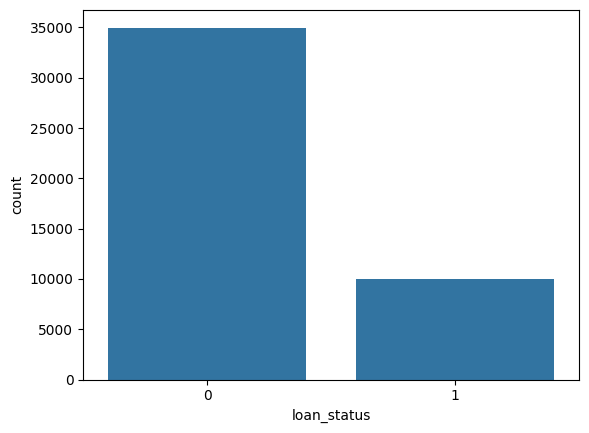

In [ ]:
#visualization:
sns.countplot(x='loan_status',data=df)

<Axes: xlabel='person_age', ylabel='Count'>

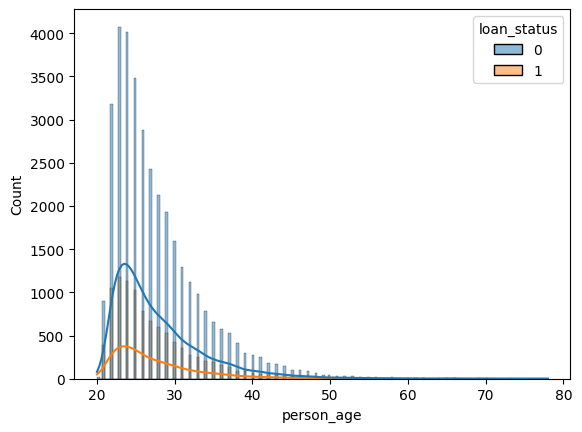

In [ ]:
sns.histplot(x='person_age',data=df,kde=True,hue='loan_status')

<Axes: xlabel='person_income', ylabel='Count'>

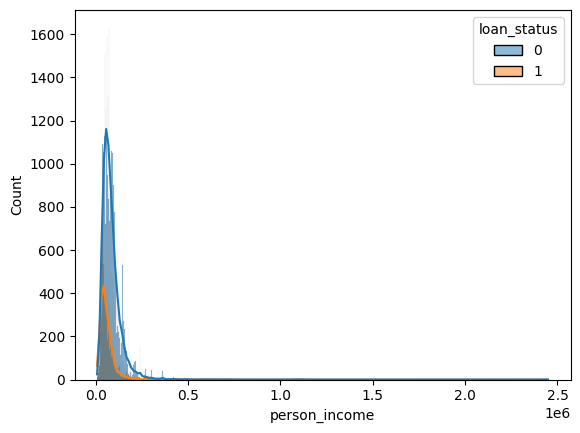

In [ ]:
sns.histplot(x='person_income',data=df,kde=True,hue='loan_status')

<Axes: xlabel='person_emp_exp', ylabel='Count'>

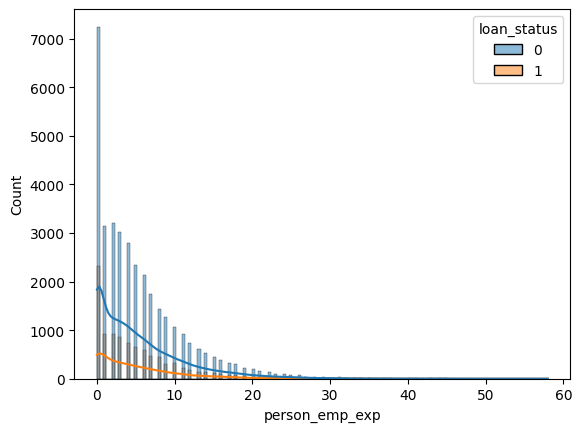

In [ ]:
sns.histplot(x='person_emp_exp',data=df,kde=True,hue='loan_status')

In [ ]:
#divide the dataset into x and y :
x=df.drop('loan_status',axis=1)
y=df['loan_status']
x
y

,loan_status
0,1
1,0
2,1
3,1
4,1
...,...
44995,1
44996,1
44997,1
44998,1


In [ ]:
#splitting the data into training and testing :
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)
xtrain
ytest

,loan_status
10795,1
5174,0
29483,0
2676,0
38073,0
...,...
28080,0
11788,1
10374,0
14467,0


**sklearn pipeline/model workflow/model pipeline**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
#divide numeric and object columns:
numeric_columns=xtrain.select_dtypes(include='number').columns
categorical_columns=xtrain.select_dtypes(include='object').columns

In [ ]:
#preprocessing pipeline:
#numceric column--------->scaling
#object column ----------->encoding
#parameter(object,class,col names)
preprocessor=ColumnTransformer([
    ('scaler:',StandardScaler(),numeric_columns),
    ('encoder:',OneHotEncoder(),categorical_columns)
])

In [ ]:
#model pipeline:
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('log_reg',LogisticRegression(class_weight='balanced'))
])

In [ ]:
#model training:
pipeline.fit(xtrain,ytrain)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler:', StandardScaler(),
                                                  Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')),
                                                 ('encoder:', OneHotEncoder(),
                                                  Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object'))])),
                ('log_reg', LogisticRegression(class_weight='balanced'))])

In [ ]:
#to get training efficiency and testing efficiency:
print('Training efficiency:',pipeline.score(xtrain,ytrain))
print('Testing efficiency:',pipeline.score(xtest,ytest))

Training efficiency: 0.8554599434795034
Testing efficiency: 0.8610802400533452


In [ ]:
ypred=pipeline.predict(xtest)
ypred

array([1, 1, 0, ..., 0, 1, 1])

In [ ]:
#classification performance metrics:
#confusion matrix:
confusion_matrix(ytest,ypred)

array([[8818, 1633],
       [ 242, 2804]])

In [ ]:
#to get the complete report of metrics of dataset:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     10451
           1       0.63      0.92      0.75      3046

    accuracy                           0.86     13497
   macro avg       0.80      0.88      0.83     13497
weighted avg       0.90      0.86      0.87     13497



In [ ]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [ ]:
#new data prediction/inference stage:
new_data=df.sample()
pipeline.predict(new_data)

array([0])

In [ ]:
df.sample()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
4220,22.0,male,Associate,39716.0,0,RENT,4500.0,MEDICAL,9.63,0.11,2.0,536,No,1


In [ ]:
#serialization: to save the model:
import pickle
with open('loan approval project(pipeline).pkl','wb')as f :
  pickle.dump(pipeline,f)

In [ ]:
#deserialization: to access the file :
with open ('loan approval project(pipeline).pkl','rb') as f:
  loaded_pipeline=pickle.load(f)

In [ ]:
loaded_pipeline.predict(new_data)

array([0])